In [ ]:
!pip install gensim scikit-learn matplotlib
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab') # Added to download the missing resource

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# Sample corpus
corpus = [
    "Studying at the university is quite exhausting sometimes",
    "I love drinking coffee while working on my assignments",
    "The university library is a great place for focused studying",
    "Coffee and snacks help me survive late night assignments"
]

In [ ]:
# Tokenize sentences
tokenized_corpus = [word_tokenize(sentence.lower()) for sentence in corpus]
print(tokenized_corpus)

[['studying', 'at', 'the', 'university', 'is', 'quite', 'exhausting', 'sometimes'], ['i', 'love', 'drinking', 'coffee', 'while', 'working', 'on', 'my', 'assignments'], ['the', 'university', 'library', 'is', 'a', 'great', 'place', 'for', 'focused', 'studying'], ['coffee', 'and', 'snacks', 'help', 'me', 'survive', 'late', 'night', 'assignments']]


In [ ]:
# Train Word2Vec model
model = Word2Vec(sentences=tokenized_corpus, vector_size=100, window=5, min_count=1, workers=4)

In [ ]:
# Save the model
model.save("word2vec.model")

model = Word2Vec.load("word2vec.model")

# Get vectors for a subset of words
words = list(model.wv.index_to_key)[:10]  # Select the first 10 words
print(words)
word_vectors = [model.wv[word] for word in words]
print(word_vectors)

['assignments', 'coffee', 'is', 'university', 'the', 'studying', 'night', 'late', 'survive', 'me']
[array([-5.4544141e-04,  2.4006085e-04,  5.0981562e-03,  9.0074250e-03,
       -9.3013365e-03, -7.1100984e-03,  6.4593069e-03,  8.9710699e-03,
       -5.0175195e-03, -3.7544854e-03,  7.3761852e-03, -1.5272109e-03,
       -4.5423559e-03,  6.5520136e-03, -4.8667728e-03, -1.8191290e-03,
        2.8741576e-03,  9.9208450e-04, -8.2832193e-03, -9.4544832e-03,
        7.3115714e-03,  5.0653443e-03,  6.7650601e-03,  7.7054999e-04,
        6.3450136e-03, -3.4056737e-03, -9.4317074e-04,  5.7709734e-03,
       -7.5303661e-03, -3.9330358e-03, -7.5087799e-03, -9.2776085e-04,
        9.5399041e-03, -7.3250108e-03, -2.3273169e-03, -1.9400317e-03,
        8.0732303e-03, -5.9290505e-03,  4.2347339e-05, -4.7489540e-03,
       -9.6002733e-03,  5.0030979e-03, -8.7693902e-03, -4.3865633e-03,
       -2.8948765e-05, -3.0250484e-04, -7.6556774e-03,  9.6139163e-03,
        4.9842056e-03,  9.2283217e-03, -8.152840

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA for dimensionality reduction
pca = PCA(n_components=2)
pca_result = pca.fit_transform(word_vectors)

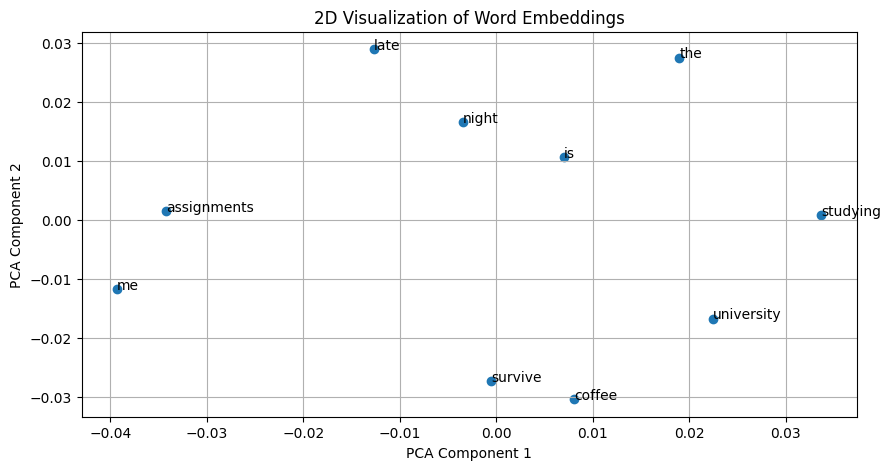

In [ ]:
import matplotlib.pyplot as plt

# Plot the words in 2D space
plt.figure(figsize=(10, 5))
plt.scatter(pca_result[:, 0], pca_result[:, 1])

# Annotate the points with the words
for i, word in enumerate(words):
    plt.annotate(word, xy=(pca_result[i, 0], pca_result[i, 1]))

plt.title("2D Visualization of Word Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()